# FIFA World Cup 2026 Prediction

> **Disclaimer:** This project is done purely for learning and educational purposes. Total runtime and system specs are printed at the end of the notebook.

## Dataset

The dataset used in this project is the [FIFA World Cup Team Dataset](https://www.kaggle.com/datasets/harrachimustapha/fifa-world-cup-team-dataset) by Mustafa Harashi, available on Kaggle. It covers World Cup tournament data from **2002 to 2026**, including team-level statistics such as FIFA ranking, historical round appearances, squad age, recent form, goal differences, and squad market value.

The 2014 historical data fix and the overall modeling approach are largely inspired by the dataset creator's own analysis notebook: [FIFA World Cup 2026 Prediction](https://www.kaggle.com/code/harrachimustapha/fifa-world-cup-2026-prediction).

## Approach

Four binary classifiers are trained per stage using chronological validation across the 2010, 2014, 2018, and 2022 editions. Candidate models (Logistic Regression, Random Forest, XGBoost, LightGBM) are evaluated using Top-K accuracy, ROC-AUC, and Brier loss, and the best-performing model per stage is selected for the final 2026 predictions. A hierarchical bracket selection then narrows down the predicted field stage by stage using cumulative scores. The top teams by cumulative score at each stage advance to the next round.

In [1]:
import time
_notebook_start = time.time()

In [2]:
%pip install pandas -q
%pip install matplotlib seaborn -q
%pip install scikit-learn xgboost lightgbm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Understanding the Dataset

**Setup:** Download the dataset from [Kaggle](https://www.kaggle.com/datasets/harrachimustapha/fifa-world-cup-team-dataset) and place the `fifa-world-cup-team-dataset` folder in the same directory as this notebook. The data is loaded with:
```python
train = pd.read_csv("fifa-world-cup-team-dataset/versions/1/train.csv")
test  = pd.read_csv("fifa-world-cup-team-dataset/versions/1/test.csv")
```

In [4]:
train = pd.read_csv("fifa-world-cup-team-dataset/versions/1/train.csv")
test  = pd.read_csv("fifa-world-cup-team-dataset/versions/1/test.csv")

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")
print()
print("Columns:", train.columns.tolist())
print()

train_missing = train.isnull().sum()
test_missing = test.isnull().sum()

print("Columns with missing values (train):")
print(train_missing[train_missing > 0])
print()
print("Columns with missing values (test):")
print(test_missing[test_missing > 0])
print()
print("Train sample:")
train.head()

Train shape: (192, 24)
Test  shape: (48, 24)

Columns: ['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before', 'winner', 'finalist', 'semi_finalist', 'quarter_finalist']

Columns with missing values (train):
squad_total_market_value_eur    32
dtype: int64

Columns with missing values (test):
winner              48
finalist            48
semi_finalist       48
quarter_finalist    48
dtype: int64

Train sample:


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,...,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,...,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,...,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,...,2,1,1,0,0,0,0,0,0,0


### Fixing the 2014 historical columns

All 32 rows for `version == 2014` have `0` across every historical-performance column (`world_cup_titles_before`, `world_cup_participations_before`, `groups_passed_before`, `round16_before`, `quarterfinals_before`, `semifinals_before`, `finals_before`). This is clearly a data quality issue, since these teams have decades of World Cup history.

These values are reconstructed using the surrounding tournament rows (2010/2018) plus a manually defined list of Round of 16 teams per edition, working forward/backward from the nearest available row for each team.

In [5]:
# Historical Round of 16 lists used to reconstruct progression counts.
ROUND16_TEAMS = {
    2002: [
        "Germany", "Paraguay", "Mexico", "United States", "Spain", "Ireland", "South Korea", "Italy",
        "Denmark", "England", "Brazil", "Belgium", "Sweden", "Senegal", "Japan", "Turkey"
    ],
    2006: [
        "Germany", "Sweden", "Argentina", "Mexico", "England", "Ecuador", "Portugal", "Netherlands",
        "Italy", "Australia", "Switzerland", "Ukraine", "Brazil", "Ghana", "Spain", "France"
    ],
    2010: [
        "Uruguay", "South Korea", "United States", "Ghana", "Netherlands", "Slovakia", "Brazil", "Chile",
        "Argentina", "Mexico", "Germany", "England", "Paraguay", "Japan", "Spain", "Portugal"
    ],
    2014: [
        "Brazil", "Chile", "Colombia", "Uruguay", "France", "Nigeria", "Germany", "Algeria",
        "Netherlands", "Mexico", "Costa Rica", "Greece", "Argentina", "Switzerland", "Belgium", "United States"
    ],
    2018: [
        "France", "Argentina", "Uruguay", "Portugal", "Spain", "Russia", "Croatia", "Denmark",
        "Brazil", "Mexico", "Belgium", "Japan", "Sweden", "Switzerland", "Colombia", "England"
    ],
    2022: [
        "Netherlands", "United States", "Argentina", "Australia", "Japan", "Croatia", "Brazil", "South Korea",
        "England", "Senegal", "France", "Poland", "Morocco", "Spain", "Portugal", "Switzerland"
    ],
}

HIST_COLS = [
    "world_cup_titles_before",
    "world_cup_participations_before",
    "groups_passed_before",
    "round16_before",
    "quarterfinals_before",
    "semifinals_before",
    "finals_before",
]


def tournament_increment(row):
    year = int(row["version"])
    team = row["team"]
    reached_r16 = int(team in ROUND16_TEAMS.get(year, []))
    return {
        "world_cup_titles_before": int(row["winner"]),
        "world_cup_participations_before": 1,
        "groups_passed_before": reached_r16,
        "round16_before": reached_r16,
        "quarterfinals_before": int(row["quarter_finalist"]),
        "semifinals_before": int(row["semi_finalist"]),
        "finals_before": int(row["finalist"]),
    }


def add_increment(values, inc, sign=1):
    values = values.copy()
    for col in HIST_COLS:
        values[col] = int(values[col]) + sign * int(inc[col])
        values[col] = max(values[col], 0)
    return values


def reconstruct_history_for_team_before_year(full_df, team, year):
    team_rows = full_df[(full_df["team"] == team) & (full_df["version"] != year)].sort_values("version")
    if team_rows.empty:
        return None

    previous_rows = team_rows[team_rows["version"] < year]
    if len(previous_rows) > 0:
        base_row = previous_rows.iloc[-1]
        values = base_row[HIST_COLS].astype(int).to_dict()
        start_year = int(base_row["version"])
        rows_to_add = full_df[(full_df["team"] == team) & (full_df["version"] >= start_year) & (full_df["version"] < year)].sort_values("version")
        for _, row in rows_to_add.iterrows():
            values = add_increment(values, tournament_increment(row), sign=1)
        return values

    future_rows = team_rows[team_rows["version"] > year]
    if len(future_rows) > 0:
        base_row = future_rows.iloc[0]
        values = base_row[HIST_COLS].astype(int).to_dict()
        end_year = int(base_row["version"])
        rows_to_subtract = full_df[(full_df["team"] == team) & (full_df["version"] >= year) & (full_df["version"] < end_year)].sort_values("version")
        for _, row in rows_to_subtract.iterrows():
            values = add_increment(values, tournament_increment(row), sign=-1)
        return values

    return None


def fix_2014_historical_columns(train_df, test_df):
    train_df = train_df.copy()
    full_df = pd.concat([train_df, test_df], ignore_index=True, sort=False)

    mask_2014 = train_df["version"] == 2014
    before_sum = train_df.loc[mask_2014, HIST_COLS].sum().sum()

    for idx, row in train_df.loc[mask_2014].iterrows():
        team = row["team"]
        values = reconstruct_history_for_team_before_year(full_df, team, 2014)
        if values is not None:
            for col in HIST_COLS:
                train_df.loc[idx, col] = values[col]

    after_sum = train_df.loc[mask_2014, HIST_COLS].sum().sum()
    print("2014 historical columns total before correction:", before_sum)
    print("2014 historical columns total after correction:", after_sum)
    return train_df

train = fix_2014_historical_columns(train, test)

display(train.loc[train["version"] == 2014, ["team"] + HIST_COLS].head(12))

2014 historical columns total before correction: 0
2014 historical columns total after correction: 675


,team,world_cup_titles_before,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before
128,Algeria,0,3,0,0,0,0,0
129,Argentina,2,15,12,7,8,4,4
130,Australia,0,3,1,1,0,0,0
131,Belgium,0,11,7,6,1,1,0
132,Bosnia and Herzegovina,0,0,0,0,0,0,0
133,Brazil,5,19,17,9,13,9,6
134,Cameroon,0,6,1,1,1,0,0
135,Chile,0,8,3,2,1,1,0
136,Colombia,0,4,1,1,0,0,0
137,Costa Rica,0,3,1,1,0,0,0


In [6]:
missing_rows = train[train['squad_total_market_value_eur'].isnull()]
print(f"Rows missing 'squad_total_market_value_eur': {len(missing_rows)}")
missing_rows.head(10)

Rows missing 'squad_total_market_value_eur': 32


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
160,2002,Argentina,South America,0,70,34,23,5,10,2,...,12,10,5,6,4,4,0,0,0,0
161,2002,Belgium,Europe,0,66,43,17,11,12,0,...,10,6,5,1,1,0,0,0,0,0
162,2002,Brazil,South America,0,144,53,38,13,12,4,...,16,14,6,10,8,5,1,1,1,1
163,2002,Cameroon,Africa,0,65,25,23,5,13,0,...,4,1,1,1,0,0,0,0,0,0
164,2002,China PR,Asia,0,126,47,29,14,12,0,...,0,0,0,0,0,0,0,0,0,0
165,2002,Costa Rica,North America,0,103,61,27,16,13,0,...,1,1,1,0,0,0,0,0,0,0
166,2002,Croatia,Europe,0,50,37,14,7,17,0,...,1,1,1,1,1,0,0,0,0,0
167,2002,Denmark,Europe,0,62,38,20,10,11,0,...,2,2,2,1,0,0,0,0,0,0
168,2002,Ecuador,South America,0,59,56,20,18,13,0,...,0,0,0,0,0,0,0,0,0,0
169,2002,England,Europe,0,65,34,17,9,14,1,...,10,8,3,6,2,1,0,0,0,1


Missing values in the train set correspond to squad_total_market_value_eur for all teams that competed in the 2002 World Cup. In the test set, the missing values are for quarter, semi, finalists, and winner, as the tournament has not yet reached those stages, and these are precisely the values my models will attempt to predict.

In [7]:
pd.set_option('display.max_rows', None)

train_teams = set(train['team'])
test_teams = set(test['team'])

print(f"Unique teams in train: {len(train_teams)}")
print(sorted(train_teams))
print()
print(f"Unique teams in test (2026): {len(test_teams)}")
print(sorted(test_teams))
print()

only_in_test = test_teams - train_teams
only_in_train = train_teams - test_teams

print(f"Teams in test but not in train ({len(only_in_test)}):")
print(sorted(only_in_test))
print()
print(f"Teams in train but not in test ({len(only_in_train)}):")
print(sorted(only_in_train))

Unique teams in train: 62
['Algeria', 'Angola', 'Argentina', 'Australia', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Cameroon', 'Canada', 'Chile', 'China PR', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', 'Denmark', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ghana', 'Greece', 'Honduras', 'Iceland', 'Iran', 'Italy', 'Ivory Coast', 'Japan', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'North Korea', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Republic of Ireland', 'Russia', 'Saudi Arabia', 'Senegal', 'Serbia', 'Serbia and Montenegro', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Turkey', 'Ukraine', 'United States', 'Uruguay', 'Wales']

Unique teams in test (2026): 48
['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia', 'Croatia', 'Cura?o', 'Czech Republic', 'DR Congo

It seems like the teams included in the train and test sets differ, which makes sense. Teams that appear in the test set but not in the train set, such as Austria, Cape Verde, and Curaçao, have not participated in any FIFA World Cup between 2002 and 2022. The same goes for teams that appear in the train set but not in the test set, these teams did compete in past tournaments but failed to qualify for 2026, so they were excluded from the test set.

## Exploratory Data Analysis

Some ideas worth exploring:

- **Target distributions**: How many teams per tournament reach each stage (`winner`, `finalist`, `semi_finalist`, `quarter_finalist`)? These should be roughly fixed counts per `version`.
- **FIFA rank vs success**: Do lower (better) `fifa_rank_pre_tournament` / higher `fifa_points_pre_tournament` correlate with going further in the tournament?
- **Squad market value vs success**: Does `squad_total_market_value_eur` separate winners/finalists from early-exit teams?
- **Host advantage**: Do hosts (`is_host == 1`) perform better than their ranking would suggest?
- **Continent breakdown**: Win rates / progression rates by `continent`.
- **Historical pedigree**: Does past performance (`world_cup_titles_before`, `semifinals_before`, etc.) predict current performance?
- **Form going in**: Relationship between `wins_last_4y` / `goals_scored_last_4y` / `goals_received_last_4y` (goal difference) and tournament outcome.
- **Squad age**: Is there a "sweet spot" `squad_avg_age` for deep runs?
- **Correlation heatmap**: Overall correlations between numeric features and the outcome columns.
- **Trends over time**: Has `squad_total_market_value_eur` or `squad_avg_age` trended up/down across World Cup editions (`version`)?

In [8]:
sns.set_theme(style="whitegrid")

train.describe()

,version,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
count,192.00000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,1.600000e+02,192.000000,...,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,2012.00000,0.036458,84.583333,44.572917,26.046875,11.052083,11.802083,0.526042,3.433053e+08,23.541667,...,6.854167,4.328125,2.760417,2.687500,1.640625,0.859375,0.031250,0.062500,0.125000,0.250000
std,6.84916,0.187918,23.731776,13.608009,6.912534,4.745612,3.496055,1.184255,3.489032e+08,18.214497,...,5.411795,4.742770,2.778921,3.743931,2.819345,1.882967,0.174448,0.242694,0.331584,0.434145
min,2002.00000,0.000000,28.000000,19.000000,8.000000,2.000000,4.000000,0.000000,6.270000e+06,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.00000,0.000000,66.000000,35.000000,21.000000,8.000000,10.000000,0.000000,9.385750e+07,9.000000,...,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2012.00000,0.000000,83.500000,42.500000,25.000000,10.500000,12.000000,0.000000,2.179400e+08,20.000000,...,5.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018.00000,0.000000,102.000000,53.250000,31.000000,14.000000,14.000000,0.000000,4.129750e+08,34.000000,...,11.000000,7.000000,5.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.250000
max,2022.00000,1.000000,156.000000,95.000000,48.000000,30.000000,23.000000,5.000000,1.620000e+09,105.000000,...,21.000000,19.000000,11.000000,16.000000,13.000000,8.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
# How many teams reach each stage per tournament?
stage_cols = ['winner', 'finalist', 'semi_finalist', 'quarter_finalist']
train.groupby('version')[stage_cols].sum()

# As expected, the number of teams that reach each stage is consistent across tournaments, with 1 winner, 2 finalists, 4 semi-finalists, and 8 quarter-finalists per tournament. 
# 2026 will follow the same pattern.

,winner,finalist,semi_finalist,quarter_finalist
version,,,,
2002,1,2,4,8
2006,1,2,4,8
2010,1,2,4,8
2014,1,2,4,8
2018,1,2,4,8
2022,1,2,4,8


,winner,finalist,semi_finalist,quarter_finalist,total_appearances
continent,,,,,
Africa,0,0,1,3,31
Asia,0,0,1,1,23
Europe,4,9,17,28,82
North America,0,0,0,2,21
Oceania,0,0,0,0,6
South America,2,3,5,14,29


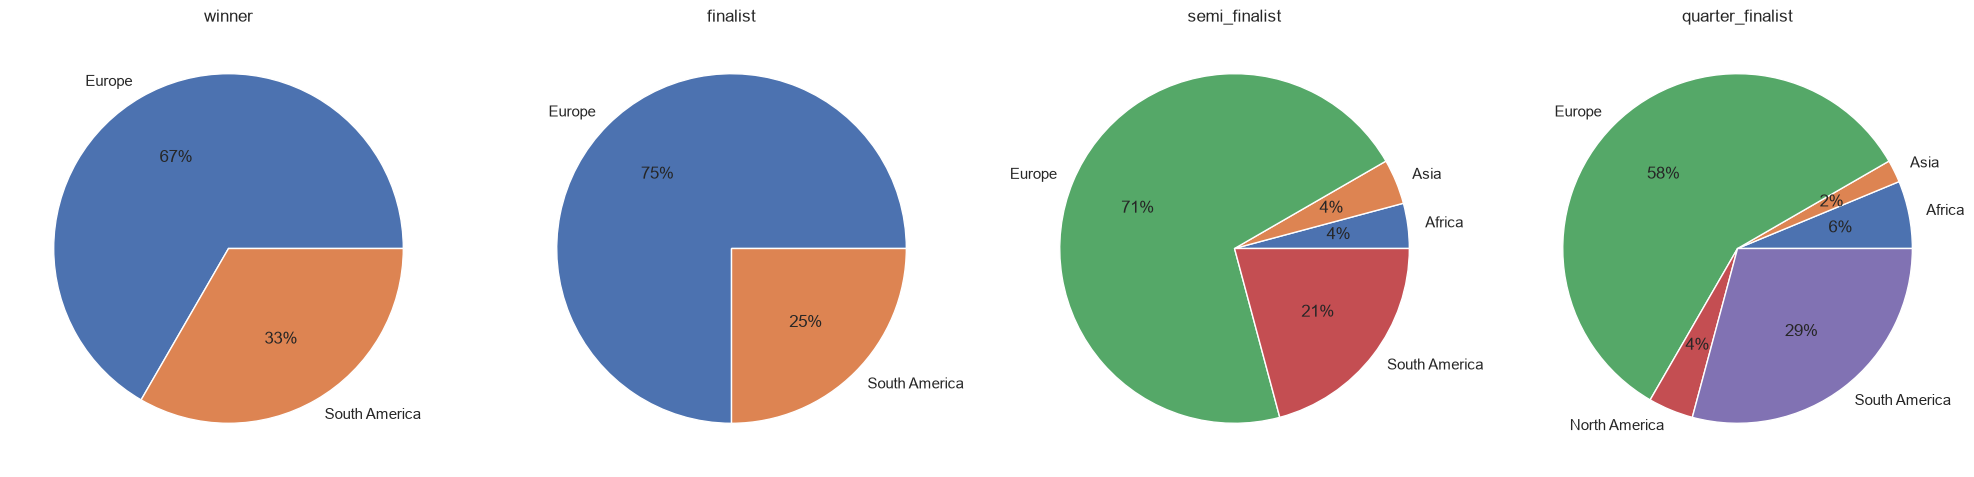

In [10]:
# Progression rate by continent
continent_progress = train.groupby('continent')[stage_cols + ['team']].agg(
    {**{c: 'sum' for c in stage_cols}, 'team': 'count'}
).rename(columns={'team': 'total_appearances'})

display(continent_progress)

fig, axes = plt.subplots(1, len(stage_cols), figsize=(5 * len(stage_cols), 5))

for ax, col in zip(axes, stage_cols):
    data = continent_progress[col]
    data = data[data > 0]
    ax.pie(data, labels=data.index, autopct='%1.0f%%')
    ax.set_title(col)

plt.tight_layout()
plt.show()

Only teams from Europe or South America have reached the finals in the past six World Cups.

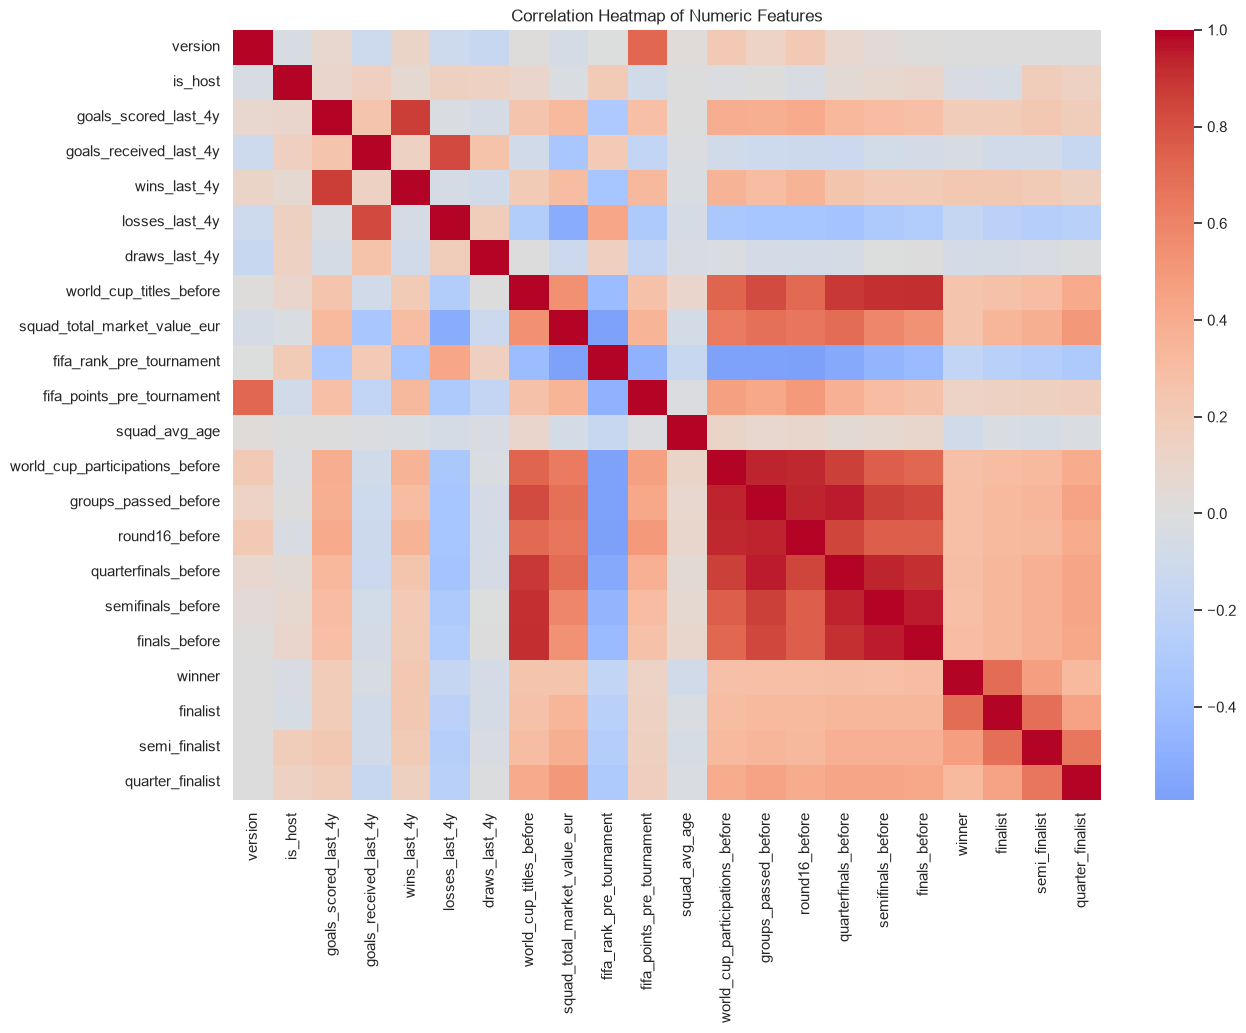

In [11]:
# Correlation between numeric features and outcome columns
numeric_cols = train.select_dtypes(include='number').columns
corr = train[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

There are some interesting observations from this heatmap. Historical performance features are tightly clustered (bottom-right block). `world_cup_participations_before`, `groups_passed_before`, `round16_before`, `quarterfinals_before`, `semifinals_before`, and `finals_before` are all strongly correlated with each other. This makes sense, teams that have historically gone far tend to do so consistently. However, this also raises a multicollinearity concern for linear models, since these features carry very similar information.

`fifa_rank_pre_tournament` is negatively correlated with outcomes. Since a lower rank number means a better team, the negative correlation with winner/finalist etc. confirms that better ranked teams advance further.

`world_cup_titles_before` stands out as it correlates with historical performance features but also shows a notable relationship with the target variables.

`squad_avg_age` and `is_host` appear largely uncorrelated with everything.

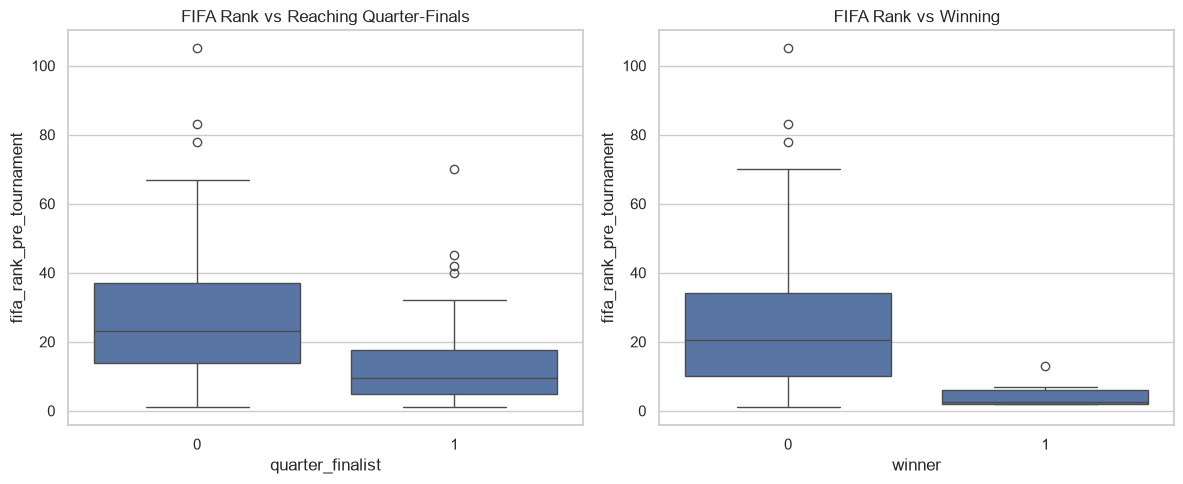

In [12]:
# FIFA rank vs how far a team progressed
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=train, x='quarter_finalist', y='fifa_rank_pre_tournament', ax=axes[0])
axes[0].set_title('FIFA Rank vs Reaching Quarter-Finals')

sns.boxplot(data=train, x='winner', y='fifa_rank_pre_tournament', ax=axes[1])
axes[1].set_title('FIFA Rank vs Winning')

plt.tight_layout()
plt.show()

Looking more into the FIFA rank, both box plots show that lower FIFA rank (better ranked teams) tend to advance further. Teams that did not reach the quarter-finals (0) have a median rank around 25 with a wide spread, meaning lower-ranked teams occasionally still make it far. Teams that did reach the quarter-finals (1) have a noticeably lower median rank (around 10), and a tighter distribution, meaning quarter-finalists are fairly consistently well-ranked teams.

Non-winners (0) show a wide spread similar to the left box plot. Winners (1) have an extremely tight, low distribution. Median rank is around 4-5 meaning World Cup winners have almost always been among the very top-ranked teams in the world at the time.

## EDA on the Test Set (2026)

The test set has no target labels, so the goal here isn't to find new patterns but to check that 2026 looks like a plausible extension of the train distribution, and to flag edge cases for the model

In [13]:
test.describe()

,version,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
count,48.0,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,0.0,0.0,0.0,0.0
mean,2026.0,0.062500,72.395833,37.604167,21.354167,8.604167,9.854167,0.375000,3.117183e+08,32.520833,...,7.041667,4.062500,3.020833,2.437500,1.479167,0.708333,NaN,NaN,NaN,NaN
std,0.0,0.244623,18.037478,12.316292,5.923231,4.150056,3.614331,1.064415,3.450467e+08,23.819346,...,5.946422,5.187572,3.479359,4.078518,2.835861,1.761990,NaN,NaN,NaN,NaN
min,2026.0,0.000000,29.000000,14.000000,9.000000,2.000000,3.000000,0.000000,5.300000e+06,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,2026.0,0.000000,63.000000,30.000000,17.500000,6.000000,7.000000,0.000000,3.762500e+07,13.750000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,2026.0,0.000000,72.000000,34.500000,21.500000,8.000000,9.000000,0.000000,1.905750e+08,27.500000,...,6.000000,2.000000,2.000000,0.500000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,2026.0,0.000000,82.250000,42.000000,26.000000,11.250000,12.000000,0.000000,4.372125e+08,47.000000,...,11.000000,7.250000,5.000000,3.000000,2.000000,0.000000,NaN,NaN,NaN,NaN
max,2026.0,1.000000,110.000000,70.000000,37.000000,20.000000,20.000000,5.000000,1.300000e+09,85.000000,...,22.000000,20.000000,12.000000,17.000000,13.000000,8.000000,NaN,NaN,NaN,NaN


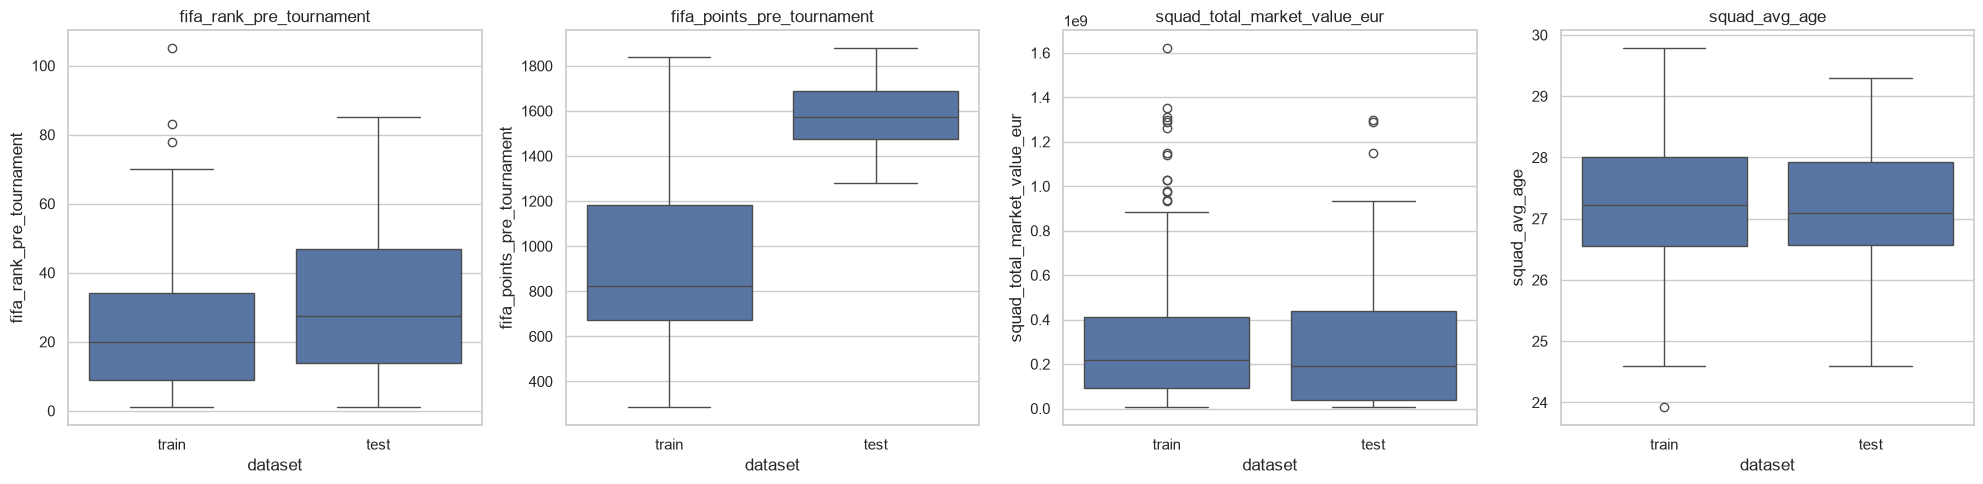

In [14]:
# Distribution shift: train vs test for key numeric features
compare_cols = ['fifa_rank_pre_tournament', 'fifa_points_pre_tournament',
                'squad_total_market_value_eur', 'squad_avg_age']

fig, axes = plt.subplots(1, len(compare_cols), figsize=(5 * len(compare_cols), 5))

for ax, col in zip(axes, compare_cols):
    sns.boxplot(data=pd.concat([
        train[[col]].assign(dataset='train'),
        test[[col]].assign(dataset='test'),
    ], ignore_index=True), x='dataset', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

The FIFA Points distribution looks much different in the test set compared to the training set.

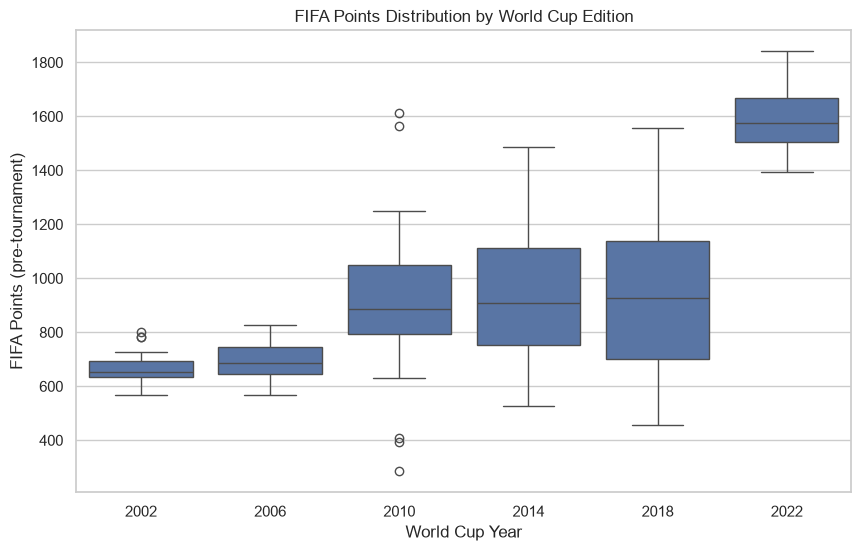

In [15]:
# Distribution of FIFA points across World Cup editions
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='version', y='fifa_points_pre_tournament')
plt.title('FIFA Points Distribution by World Cup Edition')
plt.xlabel('World Cup Year')
plt.ylabel('FIFA Points (pre-tournament)')
plt.show()

After some research, I found that FIFA made a major change to its men's national team ranking system in 2018, and it was first used after the 2018 World Cup. This explains why the FIFA points distribution for 2022 and 2026 is significantly higher compared to earlier years. Since FIFA rank is also available and remains comparable across years, it may be worth dropping `fifa_points_pre_tournament` and keeping `fifa_rank_pre_tournament` for modeling.

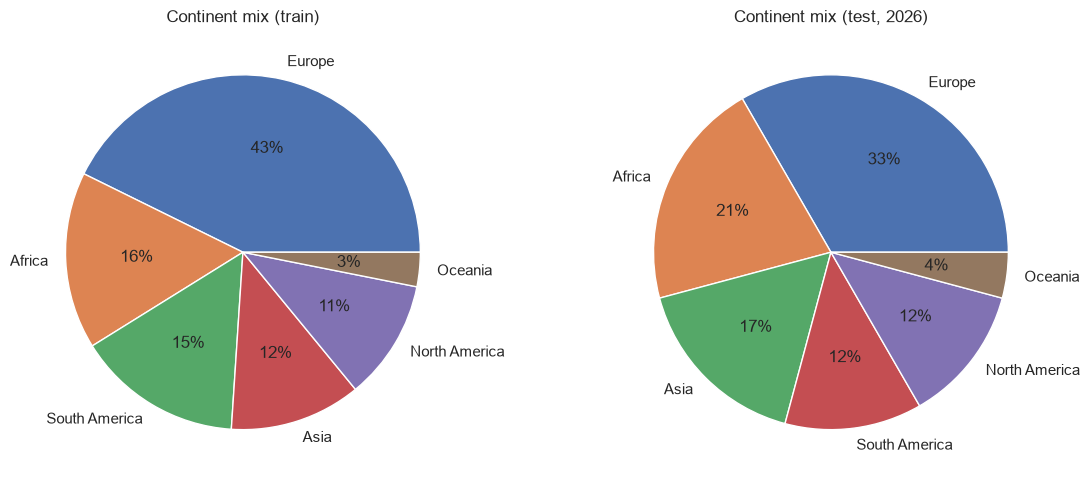

In [16]:
# Continent mix: train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train['continent'].value_counts().plot.pie(ax=axes[0], autopct='%1.0f%%')
axes[0].set_title('Continent mix (train)')
axes[0].set_ylabel('')

test['continent'].value_counts().plot.pie(ax=axes[1], autopct='%1.0f%%')
axes[1].set_title('Continent mix (test, 2026)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [17]:
# Hosts: 2026 has 3 hosts (USA, Mexico, Canada) vs the usual 1
print("Hosts per tournament (train):")
print(train[train['is_host'] == 1].groupby('version')['team'].apply(list))
print()
print(f"Hosts in test (2026): {test[test['is_host'] == 1]['team'].tolist()}")

Hosts per tournament (train):
version
2002    [Japan, South Korea]
2006               [Germany]
2010          [South Africa]
2014                [Brazil]
2018                [Russia]
2022                 [Qatar]
Name: team, dtype: object

Hosts in test (2026): ['Mexico', 'United States', 'Canada']


In [18]:
# Debutant teams: no World Cup history ever in this dataset
pedigree_cols = ['world_cup_participations_before', 'groups_passed_before', 'round16_before',
                  'quarterfinals_before', 'semifinals_before', 'finals_before', 'world_cup_titles_before']

debutants = test[test['world_cup_participations_before'] == 0]
print(f"Debutant teams in test (2026): {len(debutants)}")
debutants[['team', 'continent'] + pedigree_cols]

Debutant teams in test (2026): 4


,team,continent,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,world_cup_titles_before
36,Uzbekistan,Asia,0,0,0,0,0,0,0
41,Jordan,Asia,0,0,0,0,0,0,0
43,Cape Verde,Africa,0,0,0,0,0,0,0
45,Cura?o,North America,0,0,0,0,0,0,0


In [19]:
# Teams absent from train (2002-2022) but with World Cup history before 2002
returning_teams = test[(test['team'].isin(only_in_test)) & (test['world_cup_participations_before'] > 0)]
print(f"Teams not in train (2002-2022) but with pre-2002 history: {len(returning_teams)}")
returning_teams[['team', 'continent'] + pedigree_cols]

Teams not in train (2002-2022) but with pre-2002 history: 6


,team,continent,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,world_cup_titles_before
21,Austria,Europe,7,4,1,2,2,0,0
27,Norway,Europe,3,2,2,0,0,0,0
33,Scotland,Europe,8,0,0,0,0,0,0
35,DR Congo,Africa,1,0,0,0,0,0,0
38,Iraq,Asia,1,0,0,0,0,0,0
46,Haiti,North America,1,0,0,0,0,0,0


These teams are unlikely to get selected by the models to qualify for quarter-finals or beyond.

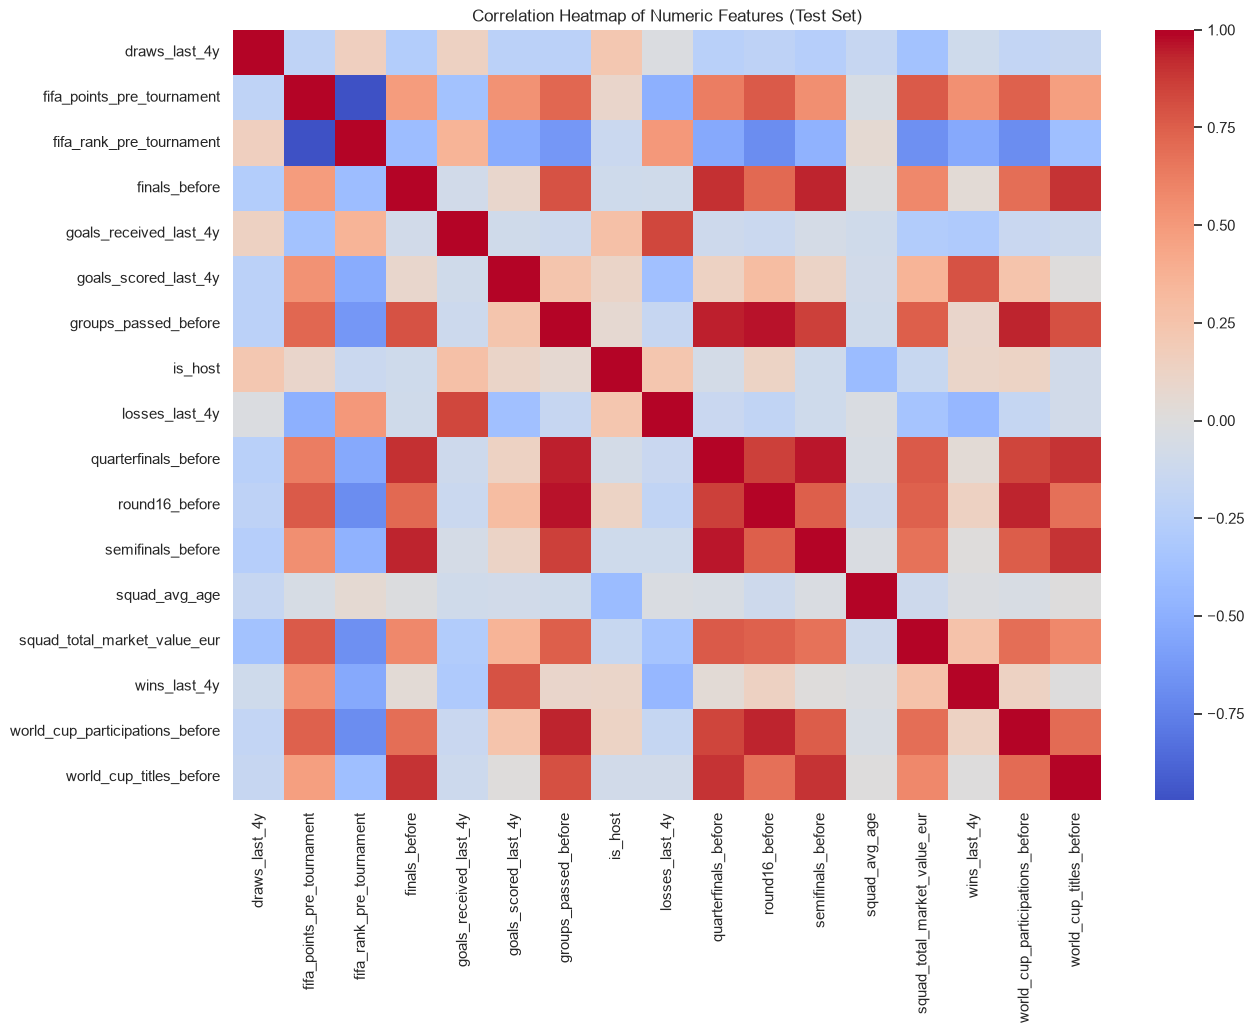

In [20]:
# Correlation between numeric features (test set)
drop_cols = ['version', 'winner', 'finalist', 'semi_finalist', 'quarter_finalist']
numeric_cols = test.select_dtypes(include='number').columns.difference(drop_cols)
corr = test[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features (Test Set)')
plt.show()

Historical performance cluster is still available with attributes `quarterfinals_before`, `round16_before`, `semifinals_before`, etc. remaining strongly correlated with each other.

`squad_total_market_value_eur` and `wins_last_4y` appear more correlated in test. Richer squads tend to win more recently, this might reflect that by 2026, wealth and performance are even more tightly linked in football than in earlier years.

## Preprocessing & Feature Engineering

Plan based on the EDA above:

1. **Targets**: keep `winner`/`finalist`/`semi_finalist`/`quarter_finalist` as separate binary targets, one model per stage (see Modeling section).
2. **Missing values**: `squad_total_market_value_eur` is missing for all 32 train rows from 2002. Add a `market_value_missing` flag and impute using each team's value from their nearest other edition (falling back to the train median).
3. **Drop `fifa_points_pre_tournament`**: not comparable pre/post 2018 ranking system change; `fifa_rank_pre_tournament` is comparable across years and I keep that instead.
4. **Keep `version`**: not used as a model feature, but kept for the chronological train/validation split in the Modeling section.
5. **New features**: `goal_diff_last_4y` (scored - received) and `win_rate_last_4y` (wins / total games last 4y).
6. **Categorical encoding**: one-hot encode `continent`. Drop `team` from model features (kept separately for identifying predictions).
7. **Exclude `squad_total_market_value_eur` from model features**: after training initial models and inspecting feature importances, this feature dominated all four stage models by a large difference. It is excluded from `FEATURES` but kept in the dataset. The `market_value_missing` imputation flag is also excluded from features as it loses its meaning once market value itself is removed.

In [21]:
# 2. Missing values: flag + impute squad_total_market_value_eur
# All missing values are 2002 rows. Instead of a global median, use each team's
# own market value from their nearest other edition (closest by "version"),
# falling back to the train median only if a team has no other rows at all.
market_value_median = train['squad_total_market_value_eur'].median()

for df in (train, test):
    df['market_value_missing'] = df['squad_total_market_value_eur'].isnull().astype(int)

def impute_market_value(row, lookup_df):
    if pd.notnull(row['squad_total_market_value_eur']):
        return row['squad_total_market_value_eur']
    team_rows = lookup_df[(lookup_df['team'] == row['team']) & lookup_df['squad_total_market_value_eur'].notnull()]
    if not team_rows.empty:
        nearest_idx = (team_rows['version'] - row['version']).abs().idxmin()
        return team_rows.loc[nearest_idx, 'squad_total_market_value_eur']
    return market_value_median

train['squad_total_market_value_eur'] = train.apply(impute_market_value, axis=1, lookup_df=train)
test['squad_total_market_value_eur'] = test.apply(impute_market_value, axis=1, lookup_df=train)

print(f"Train rows flagged as imputed: {train['market_value_missing'].sum()}")
print(f"Test rows flagged as imputed: {test['market_value_missing'].sum()}")
print(f"Fallback median (used only if a team has no other rows): {market_value_median:,.0f}")

Train rows flagged as imputed: 32
Test rows flagged as imputed: 0
Fallback median (used only if a team has no other rows): 217,940,000


In [22]:
# 5. New features: goal difference and win rate over the last 4 years
for df in (train, test):
    df['goal_diff_last_4y'] = df['goals_scored_last_4y'] - df['goals_received_last_4y']
    total_games = df['wins_last_4y'] + df['losses_last_4y'] + df['draws_last_4y']
    df['win_rate_last_4y'] = df['wins_last_4y'] / total_games

train[['team', 'goals_scored_last_4y', 'goals_received_last_4y', 'goal_diff_last_4y', 'win_rate_last_4y']].head()

,team,goals_scored_last_4y,goals_received_last_4y,goal_diff_last_4y,win_rate_last_4y
0,Angola,61,49,12,0.413043
1,Argentina,97,55,42,0.607843
2,Australia,101,34,67,0.638889
3,Brazil,117,47,70,0.535714
4,Costa Rica,89,84,5,0.419355


In [23]:
# 3, 4, 6. Drop unused columns, one-hot encode continent, build feature matrices
# "version" is kept (for chronological splitting) but excluded from FEATURES.

TARGETS = ['quarter_finalist', 'semi_finalist', 'finalist', 'winner']
TARGET_K = {'quarter_finalist': 8, 'semi_finalist': 4, 'finalist': 2, 'winner': 1}

model_train = train.drop(columns=['team', 'fifa_points_pre_tournament']) # FIFA points is dropped and rank is kept only
model_train = pd.get_dummies(model_train, columns=['continent'])

model_test = test.drop(columns=['team', 'fifa_points_pre_tournament'] + TARGETS, errors='ignore')
model_test = pd.get_dummies(model_test, columns=['continent'])

EXCLUDE_FEATURES = {'version', 'squad_total_market_value_eur', 'market_value_missing'} | set(TARGETS)
FEATURES = [c for c in model_train.columns if c not in EXCLUDE_FEATURES]

# Align one-hot continent columns between train/test feature sets
train_features, test_features = model_train[FEATURES].align(model_test[FEATURES], join='left', axis=1, fill_value=0)
model_train[FEATURES] = train_features
model_test = model_test.reindex(columns=test_features.columns, fill_value=0)
model_test[FEATURES] = test_features

print(f"Number of features: {len(FEATURES)}")
print(FEATURES)

Number of features: 23
['is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'fifa_rank_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before', 'goal_diff_last_4y', 'win_rate_last_4y', 'continent_Africa', 'continent_Asia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_South America']


## Modeling
1. Per-stage binary targets
2. Chronological validation
3. Top-K accuracy (and other metrics)
4. Cumulative scoring for 2026

### 1. Per-stage binary targets

Instead of one ordinal `stage_reached` column (didn't qualify < QF < SF < Finalist < Winner), I split the problem into four separate yes/no questions, each with its own model:

- "Will this team reach the quarter-finals?" -> `quarter_finalist`
- "Will this team reach the semi-finals?" -> `semi_finalist`
- "Will this team reach the final?" -> `finalist`
- "Will this team win it all?" -> `winner`

Each model predicts a *probability* for its question via `predict_proba`, rather than a single ranked category. This is simpler for each model to learn (binary yes/no vs. 5 ordered categories), and it matches how the final 2026 predictions are used: a team's chance of reaching each stage independently, later chained together (see part 4).

`TARGETS` and `TARGET_K` (defined earlier, in the preprocessing section) capture this: `TARGET_K` records how many teams reach each stage per tournament (8 QF, 4 SF, 2 finalists, 1 winner), used for the top-K metric in part 3.

### 2. Chronological validation

A **validation set** is data held back from training so we can check whether the model generalizes to data it hasn't seen, rather than just memorizing the training examples.

Because I'll ultimately train on 2002-2022 to predict the unseen 2026 tournament, I validate the same way: train only on editions *before* a given year, and check predictions against that year's real results. Each validation year is its own separate experiment:

- Train on 2002+2006 → check predictions against 2010
- Train on 2002+2006+2010 → check predictions against 2014
- Train on 2002+2006+2010+2014 → check predictions against 2018
- Train on 2002+2006+2010+2014+2018 → check predictions against 2022

(`VALIDATION_YEARS = [2010, 2014, 2018, 2022]`)

I then average results across all 4 experiments to get one overall sense of "how good is this model at predicting an unseen future World Cup?" This is more honest than a random train/test split, since it mirrors the real situation: when predicting 2026, there's only ever past data to train on.

The cell below sets up the validation years, the 4 candidate models (Logistic Regression, Random Forest, XGBoost, LightGBM), and helper functions used to run this validation loop.

In [24]:
# Candidate models and helper functions
VALIDATION_YEARS = [2010, 2014, 2018, 2022]

def get_candidate_models(scale_pos_weight=1.0):
    return {
        "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=5, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1),
        "XGBoost": XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
        "LightGBM": LGBMClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, class_weight="balanced", random_state=42, verbose=-1),
    }

def make_pipeline(model):
    # Only Logistic Regression needs feature scaling, tree-based models are invariant to it.
    if isinstance(model, LogisticRegression):
        return Pipeline(steps=[("scaler", StandardScaler()), ("model", model)])
    return Pipeline(steps=[("model", model)])

def predict_positive_probability(pipeline, X):
    proba = pipeline.predict_proba(X)
    classes = list(pipeline.named_steps["model"].classes_)
    if 1 in classes:
        return proba[:, classes.index(1)]
    return np.zeros(len(X))

def scale_pos_weight_for(df, target):
    n_pos = df[target].sum()
    n_neg = len(df) - n_pos
    return n_neg / n_pos if n_pos > 0 else 1.0

### 3. Top-K accuracy (and other metrics)

Each World Cup has a *fixed* number of teams that reach each stage: 8 reach the quarter-finals, 4 the semis, 2 the final, 1 wins (`TARGET_K`). **Top-K accuracy** asks: take the model's predicted probabilities for every team in a validation year, sort them highest to lowest, and look at the top K. What fraction of those K teams *actually* reached that stage?

This makes more sense than plain accuracy here, a model that predicts "no" for every team would already look highly "accurate" (most teams don't reach the QF), but would be useless. Top-K forces the model to rank the right teams highest.

Two secondary metrics are also tracked:

- **ROC-AUC**: does the model generally rank teams that advanced above teams that didn't, regardless of cutoff (0.5 = random, 1.0 = perfect).
- **Brier loss**: how close the predicted probabilities are to the true 0/1 outcomes, lower is better.

These matter because top-K accuracy can be coarse and noisy (especially for `finalist`/`winner`, where K is 1-2 and there are only 4 validation years). When models tie on top-K, ROC-AUC and Brier loss act as tiebreakers when picking the best model per target.

In [25]:
def top_k_accuracy(y_true, y_score, k):
    order = np.argsort(-y_score)[:k]
    return float(np.sum(np.asarray(y_true)[order])) / k

In [26]:
# Chronological validation: train on editions before val_year, evaluate on val_year
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

all_results = []
for target in TARGETS:
    k = TARGET_K[target]
    for val_year in VALIDATION_YEARS:
        train_part = model_train[model_train["version"] < val_year]
        val_part = model_train[model_train["version"] == val_year]

        if train_part[target].nunique() < 2:
            continue

        spw = scale_pos_weight_for(train_part, target)

        for model_name, model in get_candidate_models(spw).items():
            pipeline = make_pipeline(model)
            pipeline.fit(train_part[FEATURES], train_part[target])
            y_score = predict_positive_probability(pipeline, val_part[FEATURES])
            y_true = val_part[target].values

            all_results.append({
                "target": target,
                "val_year": val_year,
                "model": model_name,
                "top_k_accuracy": top_k_accuracy(y_true, y_score, k),
                "roc_auc": roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
                "brier_loss": brier_score_loss(y_true, y_score),
            })

results_df = pd.DataFrame(all_results)
summary = results_df.groupby(["target", "model"]).agg(
    mean_top_k_accuracy=("top_k_accuracy", "mean"),
    mean_roc_auc=("roc_auc", "mean"),
    mean_brier_loss=("brier_loss", "mean"),
).reset_index()
summary = summary.sort_values(["target", "mean_top_k_accuracy", "mean_roc_auc"], ascending=[True, False, False])

best_model_names = {}
for target in TARGETS:
    subset = summary[summary["target"] == target].sort_values(
        ["mean_top_k_accuracy", "mean_roc_auc", "mean_brier_loss"], ascending=[False, False, True]
    )
    best_model_names[target] = subset.iloc[0]["model"]

display(summary)
print("\nBest model by target:")
for target, model_name in best_model_names.items():
    print(f"{target}: {model_name}")

,target,model,mean_top_k_accuracy,mean_roc_auc,mean_brier_loss
3,finalist,XGBoost,0.37500,0.837500,0.073170
0,finalist,LightGBM,0.25000,0.833333,0.075786
1,finalist,Logistic Regression,0.12500,0.866667,0.130526
2,finalist,Random Forest,0.12500,0.802083,0.108650
6,quarter_finalist,Random Forest,0.56250,0.770833,0.178483
7,quarter_finalist,XGBoost,0.53125,0.740885,0.192359
5,quarter_finalist,Logistic Regression,0.50000,0.770833,0.192832
4,quarter_finalist,LightGBM,0.50000,0.717448,0.203257
10,semi_finalist,Random Forest,0.43750,0.767857,0.142716
11,semi_finalist,XGBoost,0.31250,0.772321,0.137587



Best model by target:
quarter_finalist: Random Forest
semi_finalist: Random Forest
finalist: XGBoost
winner: Logistic Regression


### 4. Hierarchical prediction for 2026

Once the best model is chosen per stage, each is retrained on all available data (2002-2022) and applied to all 48 teams in the 2026 test set. Each team receives 4 independent probabilities from their respective model:

- `p_quarter_finalist`, `p_semi_finalist`, `p_finalist`, `p_winner`

These are then chained into cumulative scores:

- `score_quarter_finalist = p_quarter_finalist`
- `score_semi_finalist = score_quarter_finalist * p_semi_finalist`
- `score_finalist = score_semi_finalist * p_finalist`
- `score_winner = score_finalist * p_winner`

The final bracket is built **hierarchically**, each stage selecting only from the previous stage's survivors:

1. Select the top 8 teams by `score_quarter_finalist` from all 48.
2. Select the top 4 from those 8 by `score_semi_finalist`.
3. Select the top 2 from those 4 by `score_finalist`.
4. Select the winner from those 2 by `score_winner`.

This ensures the bracket is always logically consistent: a team cannot appear as a finalist without first being selected as a quarter-finalist and semi-finalist.

In [27]:
# Retrain the best model per target on the full training set and predict 2026
predictions = test[["team", "continent"]].copy()
fitted_pipelines = {}

for target in TARGETS:
    spw = scale_pos_weight_for(model_train, target)
    model_name = best_model_names[target]
    model = get_candidate_models(spw)[model_name]
    pipeline = make_pipeline(model)
    pipeline.fit(model_train[FEATURES], model_train[target])
    fitted_pipelines[target] = pipeline
    predictions[f"p_{target}"] = predict_positive_probability(pipeline, model_test[FEATURES])

predictions["score_quarter_finalist"] = predictions["p_quarter_finalist"]
predictions["score_semi_finalist"]    = predictions["score_quarter_finalist"] * predictions["p_semi_finalist"]
predictions["score_finalist"]         = predictions["score_semi_finalist"]    * predictions["p_finalist"]
predictions["score_winner"]           = predictions["score_finalist"]         * predictions["p_winner"]

# Hierarchical selection: each stage narrows down from the previous stage's pool.
pool_qf     = predictions.sort_values("score_quarter_finalist", ascending=False).head(8)
pool_sf     = pool_qf.sort_values("score_semi_finalist",        ascending=False).head(4)
pool_f      = pool_sf.sort_values("score_finalist",             ascending=False).head(2)
pool_winner = pool_f.sort_values("score_winner",                ascending=False).head(1)

print("Quarter-finalists (top 8 of 48):")
display(pool_qf[["team", "continent", "score_quarter_finalist"]].reset_index(drop=True))

print("Semi-finalists:")
display(pool_sf[["team", "continent", "score_semi_finalist"]].reset_index(drop=True))

print("Finalists:")
display(pool_f[["team", "continent", "score_finalist"]].reset_index(drop=True))

print("Predicted winner:")
display(pool_winner[["team", "continent", "score_winner"]].reset_index(drop=True))

Quarter-finalists (top 8 of 48):


,team,continent,score_quarter_finalist
0,Argentina,South America,0.878971
1,Spain,Europe,0.792734
2,England,Europe,0.743479
3,Netherlands,Europe,0.727829
4,France,Europe,0.718205
5,Sweden,Europe,0.701396
6,Belgium,Europe,0.589041
7,Uruguay,South America,0.574774


Semi-finalists:


,team,continent,score_semi_finalist
0,Spain,Europe,0.649075
1,England,Europe,0.606726
2,Argentina,South America,0.574309
3,France,Europe,0.521059


Finalists:


,team,continent,score_finalist
0,France,Europe,0.462868
1,England,Europe,0.247263


Predicted winner:


,team,continent,score_winner
0,France,Europe,0.31668


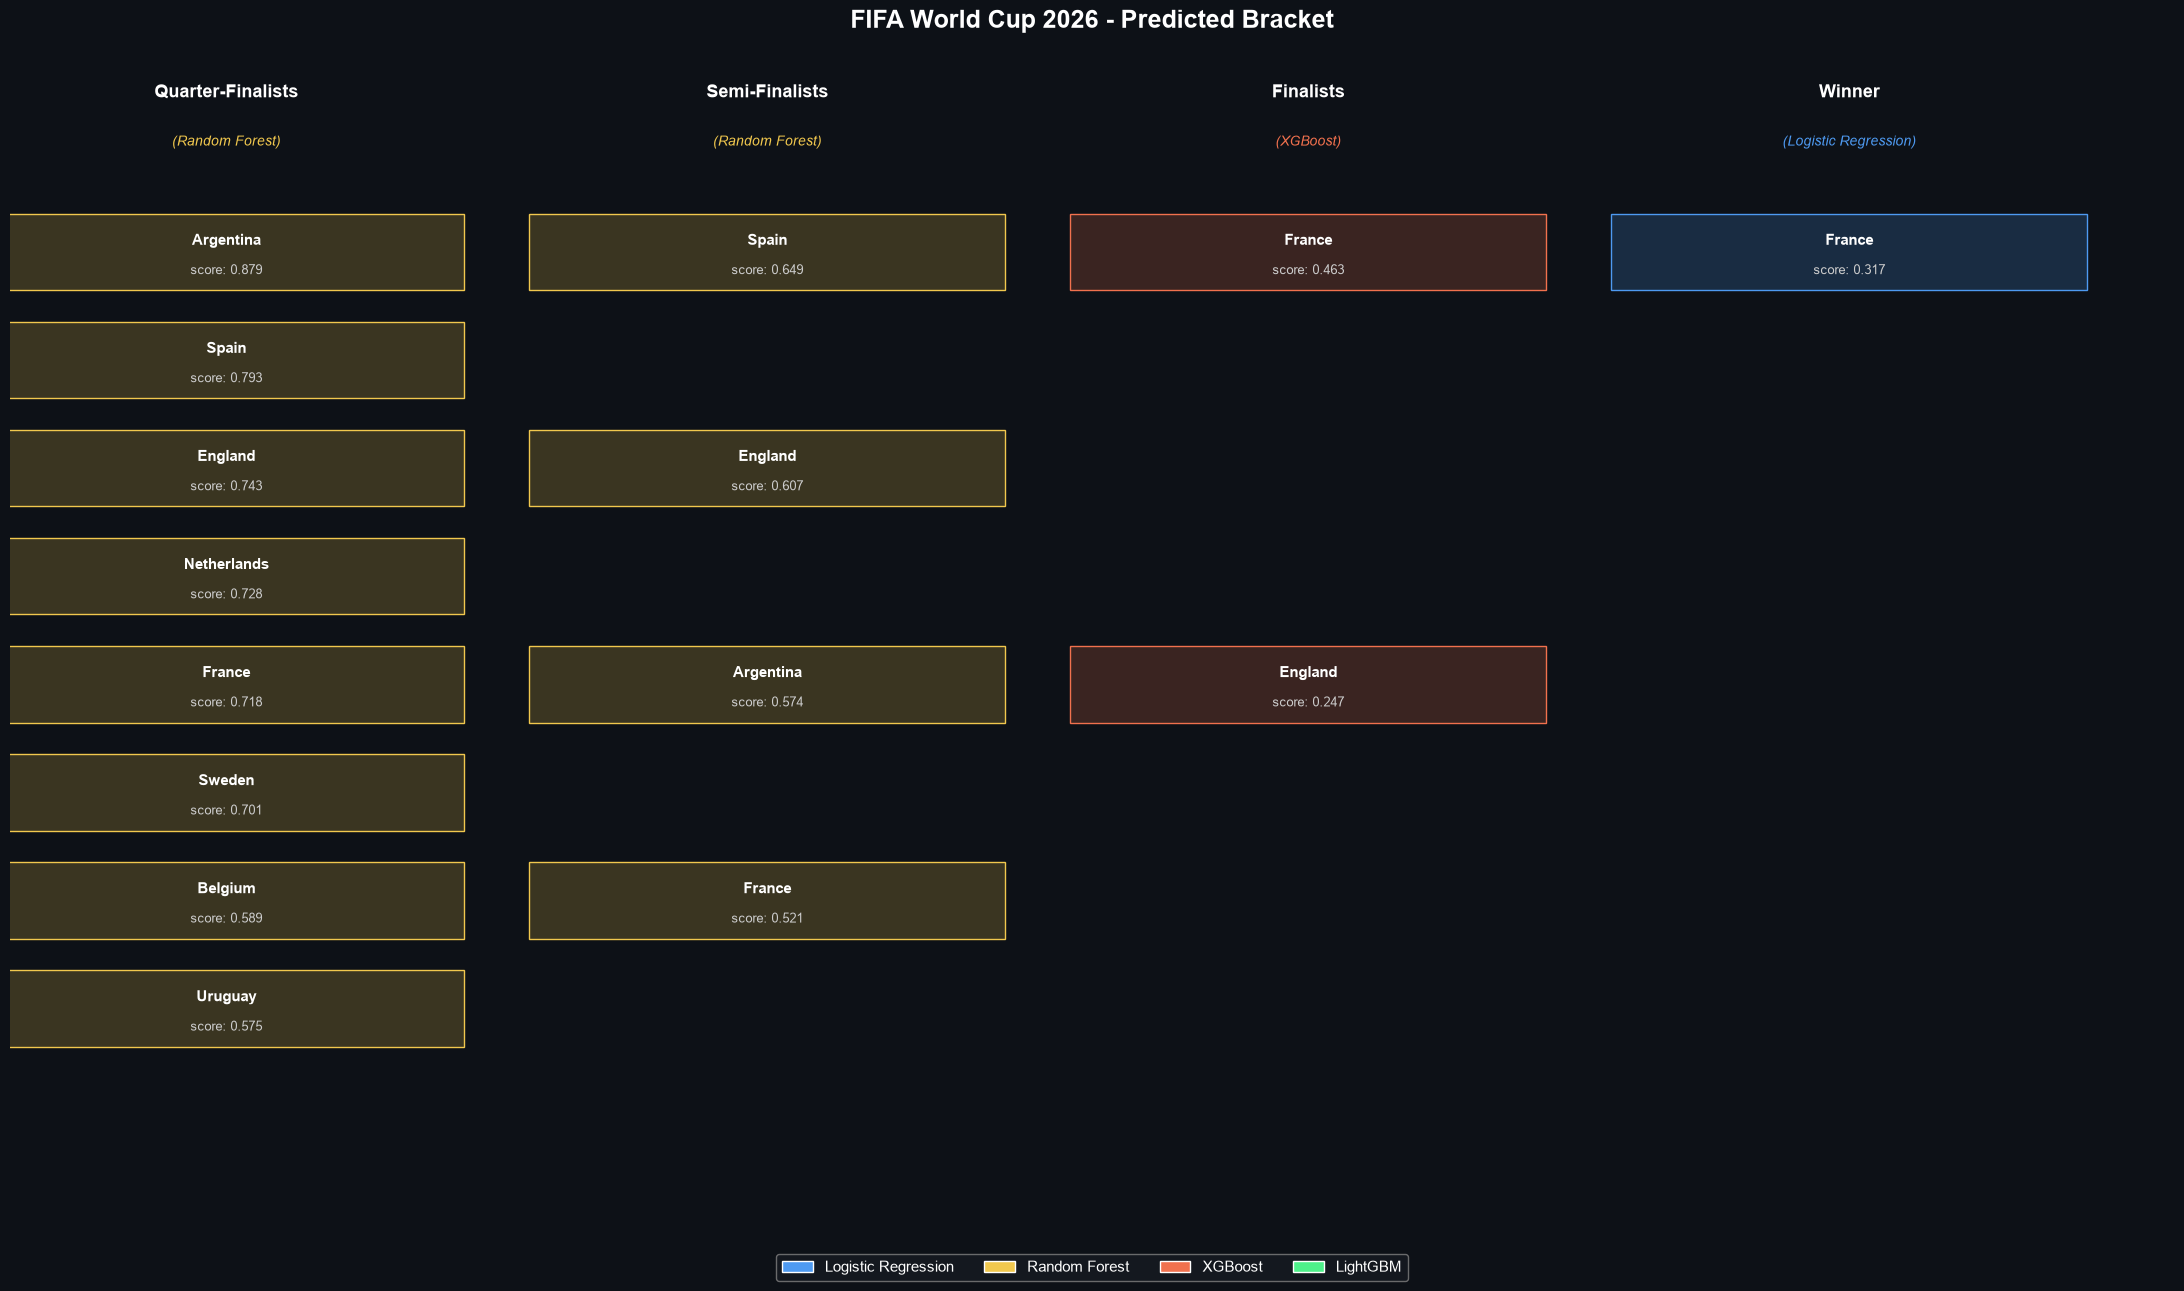

In [28]:
# Predicted bracket
MODEL_COLORS = {
    "Logistic Regression": "#4e9af1",
    "Random Forest":       "#f1c84e",
    "XGBoost":             "#f1714e",
    "LightGBM":            "#4ef18a",
}

bracket_pools = {
    "quarter_finalist": pool_qf,
    "semi_finalist":    pool_sf,
    "finalist":         pool_f,
    "winner":           pool_winner,
}

fig, ax = plt.subplots(figsize=(22, 13))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")
ax.set_xlim(0, 10)
ax.set_ylim(-0.8, 8.8)
ax.axis("off")
ax.set_title("FIFA World Cup 2026 - Predicted Bracket", color="white", fontsize=18, fontweight="bold", pad=20)

col_x      = [1.0, 3.5, 6.0, 8.5]
col_labels  = ["Quarter-Finalists", "Semi-Finalists", "Finalists", "Winner"]
col_targets = ["quarter_finalist", "semi_finalist", "finalist", "winner"]
col_scores  = ["score_quarter_finalist", "score_semi_finalist", "score_finalist", "score_winner"]
col_k       = [8, 4, 2, 1]

for cx, label, target, score_col, k in zip(col_x, col_labels, col_targets, col_scores, col_k):
    model_name  = best_model_names[target]
    model_color = MODEL_COLORS[model_name]
    ax.text(cx, 8.5, label, color="white", fontsize=13, fontweight="bold", ha="center", va="center")
    ax.text(cx, 8.1, f"({model_name})", color=model_color, fontsize=10, ha="center", va="center", style="italic")
    for rank, (_, row) in enumerate(bracket_pools[target].sort_values(score_col, ascending=False).iterrows()):
        y = 7.2 - rank * (7.0 / max(k, 1))
        ax.add_patch(plt.Rectangle((cx - 1.1, y - 0.30), 2.2, 0.62,
                                   facecolor=model_color + "33", edgecolor=model_color, linewidth=1.0, zorder=2))
        ax.text(cx, y + 0.10, row["team"], color="white", fontsize=11, ha="center", va="center", fontweight="bold", zorder=3)
        ax.text(cx, y - 0.14, f"score: {row[score_col]:.3f}", color="#cccccc", fontsize=9, ha="center", va="center", zorder=3)

ax.legend(handles=[plt.Rectangle((0,0),1,1,facecolor=c,label=m) for m,c in MODEL_COLORS.items()],
          loc="lower center", ncol=4, fontsize=11, labelcolor="white",
          facecolor="#161b22", edgecolor="gray", bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

In [ ]:
# Full rankings table for all 48 teams, ordered by predicted score for reaching the quarter-finals (score_quarter_finalist)
score_cols = ["score_quarter_finalist", "score_semi_finalist", "score_finalist", "score_winner"]
prob_cols  = ["p_quarter_finalist", "p_semi_finalist", "p_finalist", "p_winner"]

full_table = (
    predictions[["team", "continent"] + prob_cols + score_cols]
    .sort_values("score_quarter_finalist", ascending=False)
    .reset_index(drop=True)
)
full_table.index += 1
full_table.index.name = "rank"

full_table[prob_cols + score_cols] = full_table[prob_cols + score_cols].round(4)

display(full_table)

,team,continent,p_quarter_finalist,p_semi_finalist,p_finalist,p_winner,score_quarter_finalist,score_semi_finalist,score_finalist,score_winner
rank,,,,,,,,,,
1,Argentina,South America,0.8790,0.6534,0.2330,0.9552,0.8790,0.5743,0.1338,0.1278
2,Spain,Europe,0.7927,0.8188,0.1809,0.5063,0.7927,0.6491,0.1174,0.0595
3,England,Europe,0.7435,0.8161,0.4075,0.1173,0.7435,0.6067,0.2473,0.0290
4,Netherlands,Europe,0.7278,0.6142,0.3149,0.0524,0.7278,0.4470,0.1408,0.0074
5,France,Europe,0.7182,0.7255,0.8883,0.6842,0.7182,0.5211,0.4629,0.3167
6,Sweden,Europe,0.7014,0.2455,0.0044,0.0032,0.7014,0.1722,0.0008,0.0000
7,Belgium,Europe,0.5890,0.4093,0.0200,0.0089,0.5890,0.2411,0.0048,0.0000
8,Uruguay,South America,0.5748,0.4171,0.0196,0.0154,0.5748,0.2397,0.0047,0.0001
9,Germany,Europe,0.5592,0.4539,0.0330,0.6579,0.5592,0.2538,0.0084,0.0055


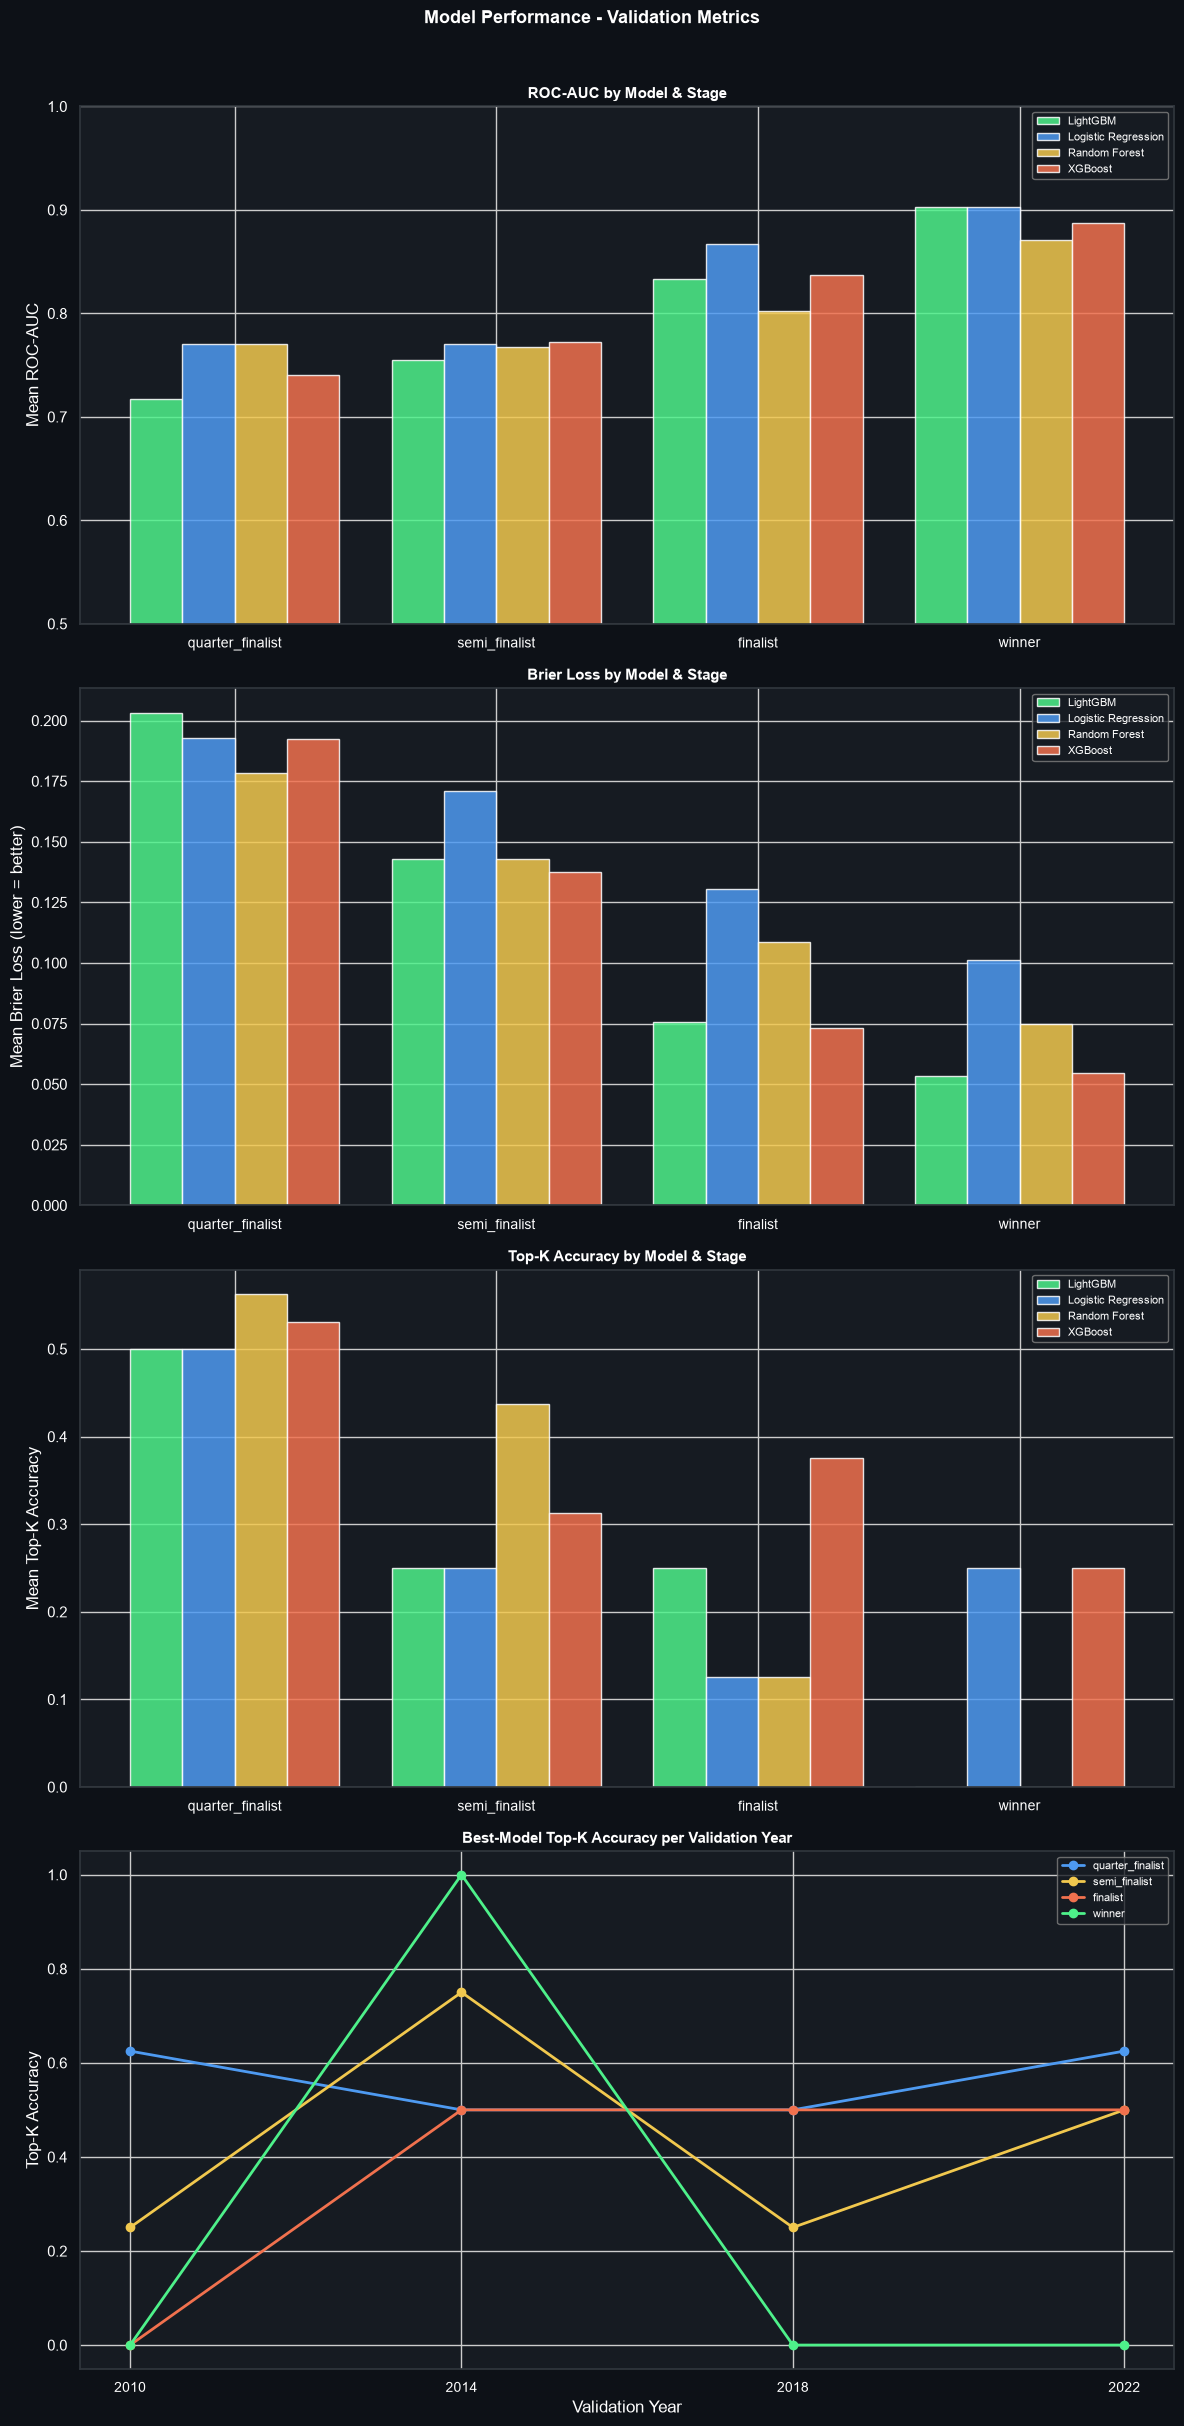

In [30]:
# Model performance metrics
fig, axes = plt.subplots(4, 1, figsize=(12, 24))
fig.patch.set_facecolor("#0d1117")
plt.suptitle("Model Performance - Validation Metrics", color="white", fontsize=13, fontweight="bold", y=1.01)

x = np.arange(len(TARGETS))
width = 0.2

def style_ax(ax, title, ylabel):
    ax.set_facecolor("#161b22")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(TARGETS, color="white", fontsize=10)
    ax.set_ylabel(ylabel, color="white")
    ax.set_title(title, color="white", fontweight="bold", fontsize=11)
    ax.tick_params(colors="white")
    ax.legend(fontsize=8, labelcolor="white", facecolor="#161b22", edgecolor="gray")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

# ROC-AUC
roc_pivot = results_df.groupby(["target", "model"])["roc_auc"].mean().unstack("model").reindex(TARGETS)
for i, m in enumerate(roc_pivot.columns):
    axes[0].bar(x + i * width, roc_pivot[m], width, label=m, color=MODEL_COLORS[m], alpha=0.85)
axes[0].set_ylim(0.5, 1.0)
style_ax(axes[0], "ROC-AUC by Model & Stage", "Mean ROC-AUC")

# Brier loss
brier_pivot = results_df.groupby(["target", "model"])["brier_loss"].mean().unstack("model").reindex(TARGETS)
for i, m in enumerate(brier_pivot.columns):
    axes[1].bar(x + i * width, brier_pivot[m], width, label=m, color=MODEL_COLORS[m], alpha=0.85)
style_ax(axes[1], "Brier Loss by Model & Stage", "Mean Brier Loss (lower = better)")

# Top-K accuracy
topk_pivot = results_df.groupby(["target", "model"])["top_k_accuracy"].mean().unstack("model").reindex(TARGETS)
for i, m in enumerate(topk_pivot.columns):
    axes[2].bar(x + i * width, topk_pivot[m], width, label=m, color=MODEL_COLORS[m], alpha=0.85)
style_ax(axes[2], "Top-K Accuracy by Model & Stage", "Mean Top-K Accuracy")

# Top-K per validation year
best_results = results_df[results_df.apply(lambda r: best_model_names[r["target"]] == r["model"], axis=1)]
topk_year = best_results.pivot_table(index="val_year", columns="target", values="top_k_accuracy").reindex(columns=TARGETS)
STAGE_COLORS = ["#4e9af1", "#f1c84e", "#f1714e", "#4ef18a"]
for col, color in zip(TARGETS, STAGE_COLORS):
    axes[3].plot(topk_year.index, topk_year[col], marker="o", label=col, color=color, linewidth=2)
axes[3].set_facecolor("#161b22")
axes[3].set_xticks(VALIDATION_YEARS)
axes[3].set_xticklabels(VALIDATION_YEARS, color="white", fontsize=10)
axes[3].set_ylabel("Top-K Accuracy", color="white")
axes[3].set_xlabel("Validation Year", color="white")
axes[3].set_title("Best-Model Top-K Accuracy per Validation Year", color="white", fontweight="bold", fontsize=11)
axes[3].set_ylim(-0.05, 1.05)
axes[3].tick_params(colors="white")
axes[3].legend(fontsize=8, labelcolor="white", facecolor="#161b22", edgecolor="gray")
for spine in axes[3].spines.values():
    spine.set_edgecolor("#30363d")

plt.tight_layout()
plt.show()

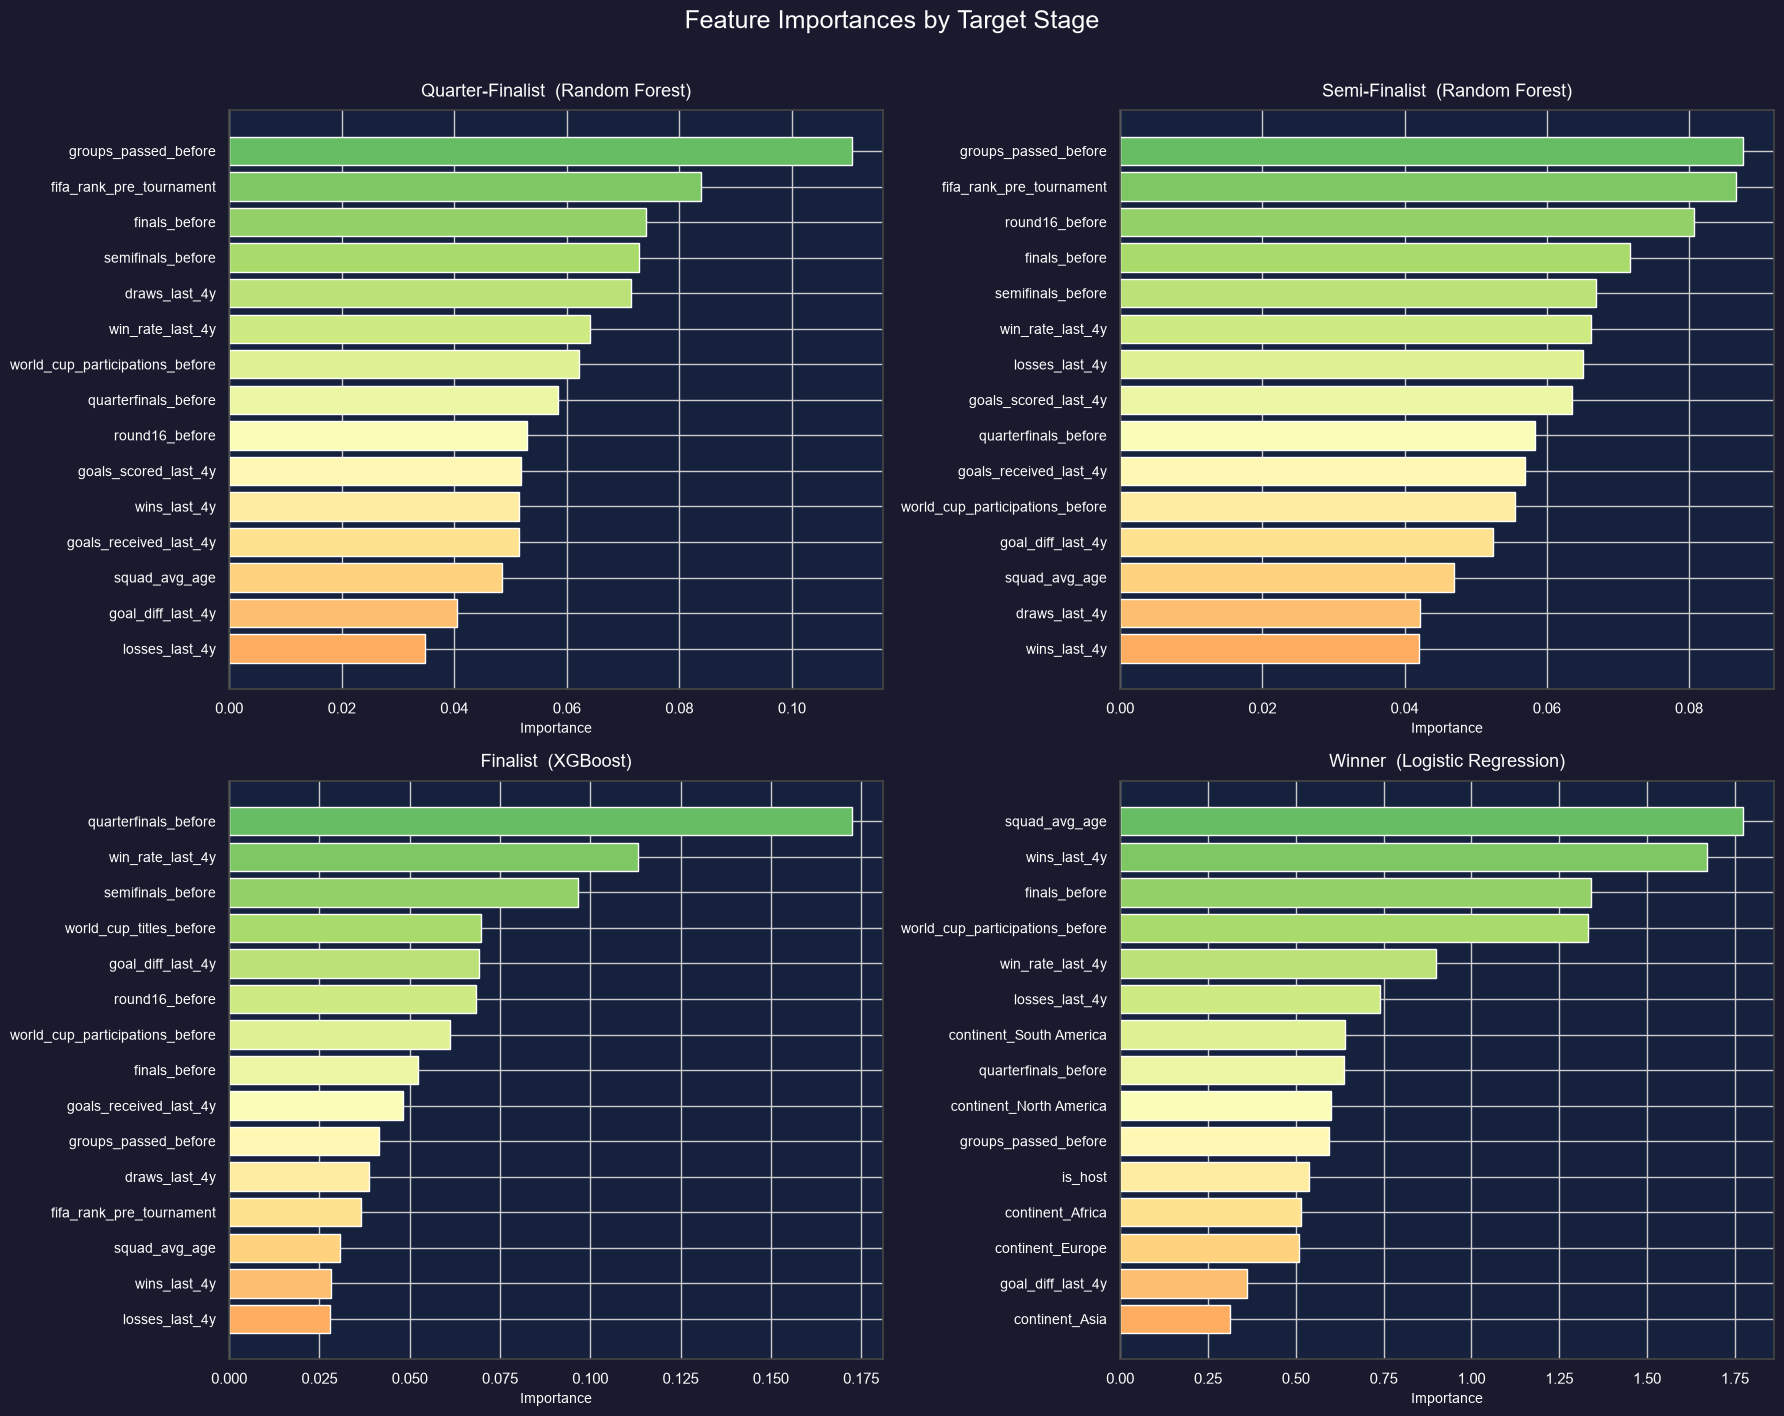

In [31]:
# Feature importances per target
import matplotlib.pyplot as plt
import numpy as np

TARGET_LABELS = {
    "quarter_finalist": "Quarter-Finalist",
    "semi_finalist":    "Semi-Finalist",
    "finalist":         "Finalist",
    "winner":           "Winner",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor("#1a1a2e")
plt.suptitle("Feature Importances by Target Stage", fontsize=18, color="white", y=1.01)

for ax, target in zip(axes.flat, TARGETS):
    ax.set_facecolor("#16213e")
    pipeline = fitted_pipelines[target]
    estimator = pipeline.steps[-1][1]
    model_name = best_model_names[target]

    if hasattr(estimator, "feature_importances_"):
        importances = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importances = np.abs(estimator.coef_[0])
    else:
        ax.set_title(TARGET_LABELS[target] + "(no importances)", color="white")
        continue

    feat_imp = sorted(zip(FEATURES, importances), key=lambda x: x[1], reverse=True)[:15]
    feats, vals = zip(*feat_imp)

    colors = plt.cm.RdYlGn(np.linspace(0.8, 0.3, len(vals)))
    ax.barh(range(len(feats)), vals[::-1], color=colors[::-1])
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats[::-1], color="white", fontsize=10)
    ax.set_title(TARGET_LABELS[target] + "  (" + model_name + ")", color="white", fontsize=13, pad=10)
    ax.set_xlabel("Importance", color="white", fontsize=10)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("#444")

plt.tight_layout()
plt.show()

In [ ]:
_elapsed = time.time() - _notebook_start
_mins, _secs = divmod(int(_elapsed), 60)
print(f"Total runtime (after all libraries are installed): {_mins}m {_secs}s")
print()
print("System specs:")
print("  CPU : AMD Ryzen 7 8845HS w/ Radeon 780M Graphics")
print("  RAM : 16 GB")

Total runtime: 0m 17s

System specs:
  CPU : AMD Ryzen 7 8845HS w/ Radeon 780M Graphics
  RAM : 16 GB
